In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/OnlineRetail.csv")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 69.3 MB


In [3]:
df.shape

(541909, 8)

In [4]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
df = df.dropna(subset=["CustomerID"])

In [6]:
df = df.drop_duplicates()

In [7]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [8]:
df["Sales"] = df["Quantity"] * df["UnitPrice"]

In [9]:
df.to_csv("../data/cleaned/cleaned_data.csv",index=False)

In [10]:
total_revenue = df["Sales"].sum()
print(f"Total Revenue = £{total_revenue:,.2f}")

Total Revenue = £8,278,519.42


### Total Revenue Analysis

The e-commerce business generated a total revenue of **£8,278,519.42** during the analysis period.

This indicates a strong sales volume and provides the foundation for further customer retention, cohort, and RFM analysis.

In [11]:
monthly_sales = df.groupby(
df["InvoiceDate"].dt.to_period("M")
)["Sales"].sum()

<Axes: xlabel='InvoiceDate'>

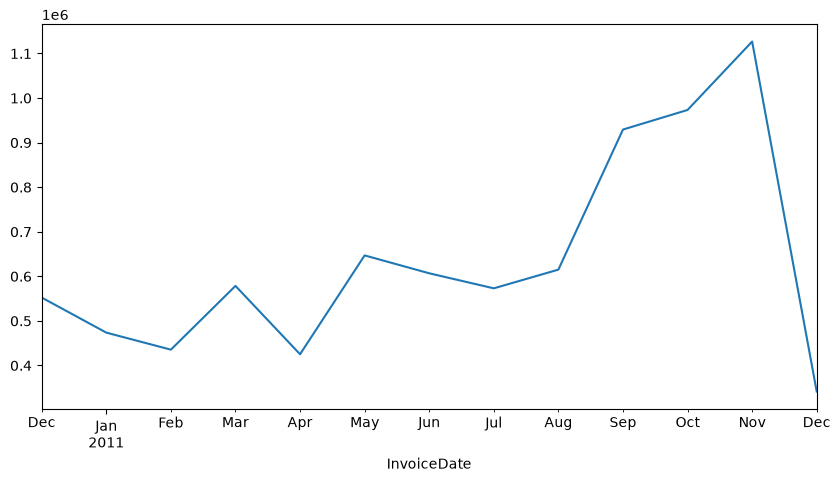

In [12]:
monthly_sales.plot(figsize=(10,5))

<Axes: xlabel='Description'>

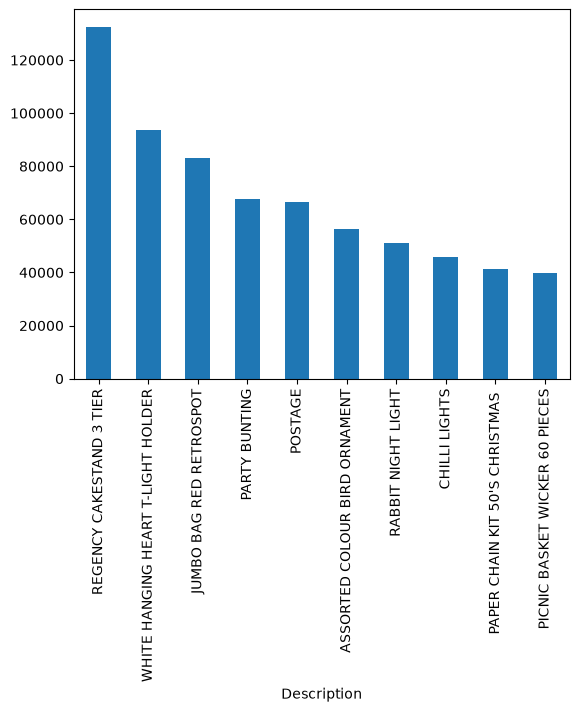

In [13]:
top_products = df.groupby(
"Description"
)["Sales"].sum().sort_values(
ascending=False
).head(10)

top_products.plot(kind="bar")

In [14]:
df["OrderMonth"] = df[
"InvoiceDate"
].dt.to_period("M")

In [15]:
cohort = df.groupby(
"CustomerID"
)["OrderMonth"].min()

In [16]:
df["CohortMonth"] = df[
"CustomerID"
].map(cohort)

In [17]:
df["CohortIndex"] = (
    (df["OrderMonth"].dt.year - df["CohortMonth"].dt.year) * 12
    + (df["OrderMonth"].dt.month - df["CohortMonth"].dt.month)
    + 1
)

In [18]:
cohort_data = df.groupby(
    ["CohortMonth", "CohortIndex"]
)["CustomerID"].nunique().reset_index()

In [19]:
cohort_counts = cohort_data.pivot(
    index="CohortMonth",
    columns="CohortIndex",
    values="CustomerID"
)

In [20]:
retention = cohort_counts.divide(
    cohort_counts.iloc[:, 0],
    axis=0
).round(3)

retention

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12,1.0,0.382,0.334,0.387,0.360,0.397,0.380,0.354,0.354,0.395,0.373,0.50,0.274
2011-01,1.0,0.240,0.283,0.242,0.328,0.299,0.261,0.257,0.311,0.347,0.368,0.15,NaN
2011-02,1.0,0.247,0.192,0.279,0.268,0.247,0.255,0.282,0.258,0.313,0.092,NaN,NaN
2011-03,1.0,0.191,0.255,0.218,0.232,0.177,0.264,0.239,0.289,0.089,NaN,NaN,NaN
2011-04,1.0,0.227,0.221,0.211,0.207,0.237,0.231,0.261,0.084,NaN,NaN,NaN,NaN
2011-05,1.0,0.237,0.172,0.172,0.215,0.244,0.265,0.104,NaN,NaN,NaN,NaN,NaN
2011-06,1.0,0.209,0.187,0.272,0.247,0.336,0.102,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,1.0,0.209,0.204,0.230,0.272,0.115,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,1.0,0.251,0.251,0.251,0.138,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


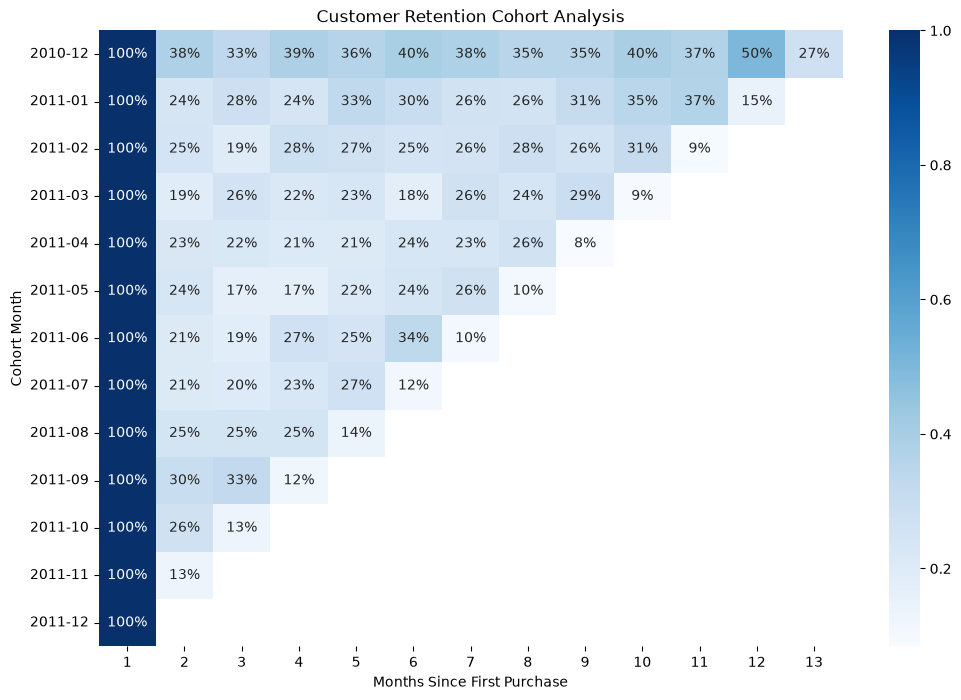

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(retention,
            annot=True,
            fmt=".0%",
            cmap="Blues")

plt.title("Customer Retention Cohort Analysis")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")

plt.show()

### Cohort Analysis Findings

Cohort analysis measures customer retention over time.

The heatmap shows the percentage of customers who returned after their first purchase month.

A declining retention rate across months is expected, but cohorts with higher retention indicate stronger customer loyalty and engagement.

This analysis helps identify opportunities to improve customer retention strategies.

RFM Analysis (Very Important for Resume)

RFM =

Recency → How recently a customer purchased
Frequency → How often they purchased
Monetary → How much money they spent

In [22]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

snapshot_date

Timestamp('2011-12-10 12:50:00')

In [23]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "Sales": "sum"
})

In [24]:
rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,2,0.00
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [25]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    4,
    labels=[4,3,2,1]
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    4,
    labels=[1,2,3,4]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    4,
    labels=[1,2,3,4]
)

In [26]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346.0,326,2,0.00,1,2,1,121
12347.0,2,7,4310.00,4,4,4,444
12348.0,75,4,1797.24,2,3,4,234
12349.0,19,1,1757.55,3,1,4,314
12350.0,310,1,334.40,1,1,2,112


In [27]:
rfm.sort_values(
    "Monetary",
    ascending=False
).head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
14646.0,2,77,279489.02,4,4,4,444
18102.0,1,62,256438.49,4,4,4,444
17450.0,8,55,187322.17,4,4,4,444
14911.0,1,248,132458.73,4,4,4,444
12415.0,24,26,123725.45,3,4,4,344
14156.0,10,66,113214.59,4,4,4,444
17511.0,3,46,88125.38,4,4,4,444
16684.0,4,31,65892.08,4,4,4,444
13694.0,4,60,62690.54,4,4,4,444


In [28]:
df.to_csv("../data/cleaned/cleaned_data.csv", index=False)

In [29]:
import os

print(os.path.exists("../data/cleaned"))

True


In [30]:
df.to_csv("../data/cleaned/cleaned_data.csv", index=False)

In [31]:
import os

os.listdir("../data/cleaned")

['cleaned_data.csv']